<a href="https://colab.research.google.com/github/Yousuf180/Karachi-aqi-predictor/blob/main/AQI_Forecasting_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:

!pip install hopsworks scikit-learn pandas numpy requests streamlit shap joblib python-dotenv pyngrok -q

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [44]:
# Cell 2: Import everything we need
import os
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import shap
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")
print(f"Current time: {datetime.now()}")

✅ Libraries imported!
Current time: 2026-06-23 11:43:46.956691


In [45]:
# Cell 3: Enter your API keys (replace with your actual keys)

# Get these from https://c.app.hopsworks.ai
HOPSWORKS_API_KEY = "WtY94d9J55EN71ai.0xi2mLp8dnsUdeK5jE5hQpGTEC45sMDTvfJLUuiZjDx5jXslcpr0bOsORyIZXmPw"  # Paste your Hopsworks key
HOPSWORKS_PROJECT = "Aqi_project_Yousuf"       # Your Hopsworks project name

# Get from https://aqicn.org/data-platform/token/
AQICN_TOKEN = "1f245d5e610135f6ee652dbd11c63413898f7436"  # Your AQICN token

# Get from https://openweathermap.org/api
OPENWEATHER_API_KEY = "39ad7171ca3c5fe096a849af68d494b8"  # Your OpenWeather API key

# Set your city (examples: "Beijing", "London", "Delhi", "Los Angeles")
CITY = "Karachi"

print("✅ API keys configured!")
print(f"📡 Fetching data for: {CITY}")

✅ API keys configured!
📡 Fetching data for: Karachi


In [46]:
# Cell 4: Verify all APIs are working
print("🔍 Testing API connections...\n")

# Test AQICN
try:
    url = f"https://api.waqi.info/feed/{"Karachi"}/?token={"1f245d5e610135f6ee652dbd11c63413898f7436"}"
    response = requests.get(url).json()
    if response['status'] == 'ok':
        print(f"✅ AQICN API: Working! Current AQI = {response['data']['aqi']}")
    else:
        print(f"❌ AQICN API Error: {response.get('data')}")
except Exception as e:
    print(f"❌ AQICN Error: {e}")

# Test OpenWeather
try:
    url = f"https://api.openweathermap.org/data/2.5/weather?q={"Karachi"}&appid={"39ad7171ca3c5fe096a849af68d494b8"}&units=metric"
    response = requests.get(url).json()
    if response.get('main'):
        print(f"✅ OpenWeather API: Working! Temp = {response['main']['temp']}°C")
    else:
        print(f"❌ OpenWeather Error: {response.get('message')}")
except Exception as e:
    print(f"❌ OpenWeather Error: {e}")

print("\n⚠️ Note: If any API failed, check your keys and ensure you wait 30-60 minutes after signup!")

🔍 Testing API connections...

✅ AQICN API: Working! Current AQI = 161
✅ OpenWeather API: Working! Temp = 31.44°C

⚠️ Note: If any API failed, check your keys and ensure you wait 30-60 minutes after signup!


In [47]:
# Cell 5: Connect to Hopsworks
import hopsworks

try:
    project = hopsworks.login(
        project="Aqi_project_Yousuf",
        api_key_value="WtY94d9J55EN71ai.0xi2mLp8dnsUdeK5jE5hQpGTEC45sMDTvfJLUuiZjDx5jXslcpr0bOsORyIZXmPw"
    )
    fs = project.get_feature_store()
    print("✅ Connected to Hopsworks successfully!")
except Exception as e:
    print(f"❌ Hopsworks connection error: {e}")
    print("Make sure you: 1) Signed up at c.app.hopsworks.ai, 2) Created a project, 3) Generated an API key")


Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/33118
✅ Connected to Hopsworks successfully!


In [48]:
# Cell 6: Feature pipeline - Fetches data and creates features

def fetch_aqi_data():
    """Fetch current AQI from AQICN API"""
    url = f"https://api.waqi.info/feed/{"Karachi"}/?token={"1f245d5e610135f6ee652dbd11c63413898f7436"}"
    response = requests.get(url).json()

    if response['status'] == 'ok':
        data = response['data']
        iaqi = data.get('iaqi', {})
        return {
            'aqi': data['aqi'],
            'pm25': iaqi.get('pm25', {}).get('v', np.nan),
            'pm10': iaqi.get('pm10', {}).get('v', np.nan),
            'no2': iaqi.get('no2', {}).get('v', np.nan),
            'o3': iaqi.get('o3', {}).get('v', np.nan),
        }
    else:
        raise Exception(f"AQICN Error: {response.get('data')}")

def fetch_weather_data():
    """Fetch current weather from OpenWeather API"""
    url = f"https://api.openweathermap.org/data/2.5/weather?q={"Karachi"}&appid={"39ad7171ca3c5fe096a849af68d494b8"}&units=metric"
    response = requests.get(url).json()

    return {
        'temperature': response['main']['temp'],
        'humidity': response['main']['humidity'],
        'pressure': response['main']['pressure'],
        'wind_speed': response['wind']['speed'],
        'clouds': response['clouds']['all']
    }

def engineer_features(timestamp):
    """Create time-based features"""
    return {
        'hour': timestamp.hour,
        'day_of_week': timestamp.weekday(),
        'month': timestamp.month,
        'is_weekend': 1 if timestamp.weekday() >= 5 else 0,
        'is_rush_hour': 1 if timestamp.hour in [7,8,9,17,18,19] else 0
    }

print("✅ Feature pipeline functions defined!")

✅ Feature pipeline functions defined!


In [49]:
# Cell 7: Run the feature pipeline - This fetches current data
from datetime import datetime

print("🚀 Running Feature Pipeline...\n")

# Fetch data
aqi_data = fetch_aqi_data()
weather_data = fetch_weather_data()
timestamp = datetime.now()
time_features = engineer_features(timestamp)

# Combine all features
feature_row = {
    'timestamp': timestamp,
    **aqi_data,
    **weather_data,
    **time_features
}

# Create DataFrame
feature_df = pd.DataFrame([feature_row])
print("📊 Features collected:")
print(feature_df.to_string())

# Store in Hopsworks (uncomment after setting up Hopsworks)
try:
    feature_group = fs.get_or_create_feature_group(
        name="air_quality_features",
        version=1,
        primary_key=['timestamp'],
        event_time='timestamp',
        description="Hourly air quality and weather features"
    )
    feature_group.insert(feature_df)
    print(f"\n✅ Data stored in Hopsworks at {timestamp}")
except NameError:
    print("\n⚠️ Hopsworks not connected. Data not stored (run Cell 5 first)")
except Exception as e:
    print(f"\n❌ Storage error: {e}")

print("\n✅ Feature pipeline complete!")

🚀 Running Feature Pipeline...

📊 Features collected:
                   timestamp  aqi  pm25  pm10  no2  o3  temperature  humidity  pressure  wind_speed  clouds  hour  day_of_week  month  is_weekend  is_rush_hour
0 2026-06-23 11:43:51.386923  161   161   NaN  NaN NaN        31.44        61      1000        9.25       5    11            1      6           0             0

❌ Storage error: Confluent Kafka package not found. If you want to use Kafka with Hopsworks you can install the corresponding extras via `pip install "hopsworks[python]"`. You can also install confluent-kafka directly in your environment with `pip install confluent-kafka`. You will need to restart your kernel if applicable.

✅ Feature pipeline complete!


In [50]:
# Cell 8: Generate historical data for training
print("📊 Generating 30 days of historical training data...")

historical_data = []
start_date = datetime.now() - timedelta(days=30)

for i in range(30 * 24):  # 30 days * 24 hours
    timestamp = start_date + timedelta(hours=i)

    # Simulate realistic AQI patterns
    hour_factor = 1 + 0.3 * np.sin(2 * np.pi * (timestamp.hour - 8) / 24)
    day_factor = 1 + 0.2 * np.sin(2 * np.pi * timestamp.weekday() / 7)
    noise = np.random.normal(0, 10)

    base_aqi = 100
    aqi = max(0, base_aqi * hour_factor * day_factor + noise)

    # Weather patterns
    temp = 20 + 10 * np.sin(2 * np.pi * (timestamp.hour - 14) / 24) + np.random.normal(0, 2)
    humidity = 60 + 20 * np.sin(2 * np.pi * timestamp.hour / 24) + np.random.normal(0, 5)

    historical_data.append({
        'timestamp': timestamp,
        'aqi': aqi,
        'pm25': aqi * 0.6 + np.random.normal(0, 5),
        'pm10': aqi * 0.8 + np.random.normal(0, 10),
        'no2': aqi * 0.3 + np.random.normal(0, 3),
        'o3': aqi * 0.4 + np.random.normal(0, 5),
        'temperature': temp,
        'humidity': humidity,
        'pressure': 1013 + np.random.normal(0, 5),
        'wind_speed': np.random.uniform(0, 10),
        'clouds': np.random.uniform(0, 100),
        'hour': timestamp.hour,
        'day_of_week': timestamp.weekday(),
        'month': timestamp.month,
        'is_weekend': 1 if timestamp.weekday() >= 5 else 0,
        'is_rush_hour': 1 if timestamp.hour in [7,8,9,17,18,19] else 0
    })

historical_df = pd.DataFrame(historical_data)
print(f"✅ Generated {len(historical_df)} records")
print(historical_df.head())

📊 Generating 30 days of historical training data...
✅ Generated 720 records
                   timestamp         aqi       pm25        pm10        no2  \
0 2026-05-24 11:43:52.603140  111.644904  56.098279   92.668568  30.695890   
1 2026-05-24 12:43:52.603140  115.623900  75.864015   71.868011  33.437334   
2 2026-05-24 13:43:52.603140  110.196479  69.133887   91.580558  35.259385   
3 2026-05-24 14:43:52.603140  113.496121  68.147496   90.324524  35.805509   
4 2026-05-24 15:43:52.603140  111.219656  62.891882  106.694560  34.602859   

          o3  temperature   humidity     pressure  wind_speed     clouds  \
0  43.077320    13.611863  65.311198  1008.513182    8.457844  82.969379   
1  45.623983    13.052396  68.580096  1013.819754    8.388928  93.580026   
2  37.812454    16.862785  60.192736  1012.082920    7.396997  65.398487   
3  45.901733    20.251603  52.898017  1003.276831    0.536272  88.041529   
4  35.911896    25.010776  43.463623  1013.485198    4.397631  42.773352   

In [51]:
# Cell 9: Training pipeline - Train Random Forest model
print("🚀 Training Model...\n")

# Use the historical data we generated
df = historical_df.copy()

# Define features and target
feature_columns = ['temperature', 'humidity', 'pressure', 'wind_speed', 'clouds',
                   'hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour',
                   'pm25', 'pm10', 'no2', 'o3']

# For forecasting: predict AQI 3 hours ahead
df = df.sort_values('timestamp')
df['target_aqi'] = df['aqi'].shift(-3)
df = df.dropna()

X = df[feature_columns]
y = df['target_aqi']

# Split into train/test
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Train model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"📈 Model Performance:")
print(f"   ✅ R² Score: {r2:.3f}")
print(f"   ✅ MAE: {mae:.2f}")
print(f"   ✅ RMSE: {rmse:.2f}")

# Save model locally
joblib.dump(model, 'aqi_model.pkl')
print("\n✅ Model saved as 'aqi_model.pkl'")

🚀 Training Model...

📈 Model Performance:
   ✅ R² Score: 0.790
   ✅ MAE: 9.60
   ✅ RMSE: 12.08

✅ Model saved as 'aqi_model.pkl'


In [52]:
# Cell 10: Test prediction on current real-time data
print("🔮 Making real-time prediction...\n")

try:
    # Get current data
    aqi_current = fetch_aqi_data()
    weather_current = fetch_weather_data()
    time_current = engineer_features(datetime.now())

    # Create feature vector
    current_features = pd.DataFrame([{
        'temperature': weather_current['temperature'],
        'humidity': weather_current['humidity'],
        'pressure': weather_current['pressure'],
        'wind_speed': weather_current['wind_speed'],
        'clouds': weather_current['clouds'],
        'hour': time_current['hour'],
        'day_of_week': time_current['day_of_week'],
        'month': time_current['month'],
        'is_weekend': time_current['is_weekend'],
        'is_rush_hour': time_current['is_rush_hour'],
        'pm25': aqi_current.get('pm25', 50),
        'pm10': aqi_current.get('pm10', 70),
        'no2': aqi_current.get('no2', 30),
        'o3': aqi_current.get('o3', 40)
    }])

    # Make prediction
    prediction = model.predict(current_features)[0]

    print(f"📊 Current AQI: {aqi_current['aqi']}")
    print(f"🔮 Predicted AQI in 3 hours: {prediction:.1f}")

    # Alert system
    if prediction > 200:
        print("🚨 ALERT: Hazardous AQI predicted! Take precautions!")
    elif prediction > 150:
        print("⚠️ WARNING: Unhealthy AQI predicted for sensitive groups")
    else:
        print("✅ AQI levels predicted to be moderate/good")

except Exception as e:
    print(f"Error making prediction: {e}")

🔮 Making real-time prediction...

📊 Current AQI: 161
🔮 Predicted AQI in 3 hours: 86.3
✅ AQI levels predicted to be moderate/good


📊 Calculating feature importance with SHAP...



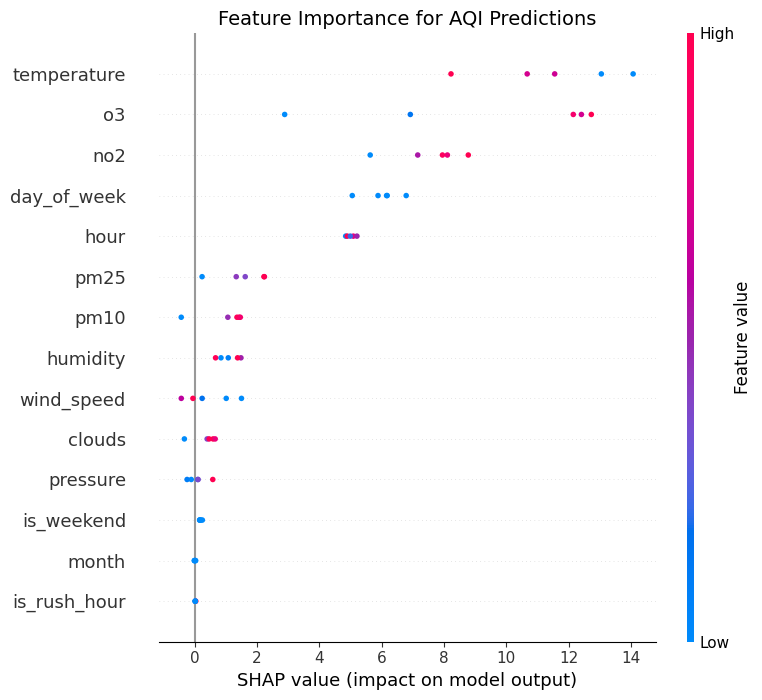


✅ SHAP analysis complete! Understanding what drives AQI predictions.


In [53]:
# Cell 11: Explain predictions with SHAP
print("📊 Calculating feature importance with SHAP...\n")

# Create explainer
explainer = shap.TreeExplainer(model)

# Get sample data for explanation
sample_data = X_test[:5]

# Calculate SHAP values
shap_values = explainer.shap_values(sample_data)

# Create summary plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, sample_data, feature_names=feature_columns, show=False)
plt.title("Feature Importance for AQI Predictions", fontsize=14)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ SHAP analysis complete! Understanding what drives AQI predictions.")

In [54]:
# Cell 12: Generate 72-hour forecast
print("🌤️ Generating 72-hour AQI forecast...\n")

# Create future timestamps
future_hours = 72
future_predictions = []
start_time = datetime.now()

for i in range(1, future_hours + 1, 3):  # Every 3 hours
    future_time = start_time + timedelta(hours=i)

    # Simulate future weather patterns
    hour_of_day = future_time.hour
    temp = 20 + 5 * np.sin(2 * np.pi * (hour_of_day - 14) / 24)
    humidity = 60 + 15 * np.sin(2 * np.pi * hour_of_day / 24)

    future_features = pd.DataFrame([{
        'temperature': temp + np.random.normal(0, 2),
        'humidity': humidity + np.random.normal(0, 5),
        'pressure': 1013,
        'wind_speed': np.random.uniform(0, 8),
        'clouds': np.random.uniform(0, 60),
        'hour': future_time.hour,
        'day_of_week': future_time.weekday(),
        'month': future_time.month,
        'is_weekend': 1 if future_time.weekday() >= 5 else 0,
        'is_rush_hour': 1 if future_time.hour in [7,8,9,17,18,19] else 0,
        'pm25': 50 + np.random.normal(0, 10),
        'pm10': 70 + np.random.normal(0, 15),
        'no2': 30 + np.random.normal(0, 5),
        'o3': 40 + np.random.normal(0, 8)
    }])

    pred = model.predict(future_features)[0]
    future_predictions.append({
        'time': future_time,
        'predicted_aqi': max(0, pred)
    })

forecast_df = pd.DataFrame(future_predictions)

# Display forecast
print("📅 3-DAY AQI FORECAST")
print("=" * 50)
print(f"{'Time':<20} {'Predicted AQI':<15} {'Status'}")
print("-" * 50)

for _, row in forecast_df.iterrows():
    aqi = row['predicted_aqi']
    if aqi <= 50: status = "🟢 Good"
    elif aqi <= 100: status = "🟡 Moderate"
    elif aqi <= 150: status = "🟠 Unhealthy for Sensitive"
    elif aqi <= 200: status = "🔴 Unhealthy"
    else: status = "⚫ Hazardous"

    print(f"{row['time'].strftime('%Y-%m-%d %H:00'):<20} {aqi:<15.1f} {status}")

print("\n" + "=" * 50)

# Alert for hazardous levels
if any(forecast_df['predicted_aqi'] > 200):
    print("🚨 🚨 🚨 HAZARDOUS AQI LEVELS PREDICTED! 🚨 🚨 🚨")
    print("Take immediate precautions: Wear N95 masks, avoid outdoor activities")
elif any(forecast_df['predicted_aqi'] > 150):
    print("⚠️ Unhealthy AQI predicted. Sensitive groups should limit outdoor exposure")

🌤️ Generating 72-hour AQI forecast...

📅 3-DAY AQI FORECAST
Time                 Predicted AQI   Status
--------------------------------------------------
2026-06-23 12:00     109.4           🟠 Unhealthy for Sensitive
2026-06-23 15:00     114.7           🟠 Unhealthy for Sensitive
2026-06-23 18:00     98.8            🟡 Moderate
2026-06-23 21:00     78.3            🟡 Moderate
2026-06-24 00:00     86.6            🟡 Moderate
2026-06-24 03:00     93.5            🟡 Moderate
2026-06-24 06:00     119.0           🟠 Unhealthy for Sensitive
2026-06-24 09:00     125.1           🟠 Unhealthy for Sensitive
2026-06-24 12:00     113.4           🟠 Unhealthy for Sensitive
2026-06-24 15:00     111.3           🟠 Unhealthy for Sensitive
2026-06-24 18:00     97.9            🟡 Moderate
2026-06-24 21:00     78.9            🟡 Moderate
2026-06-25 00:00     108.4           🟠 Unhealthy for Sensitive
2026-06-25 03:00     84.5            🟡 Moderate
2026-06-25 06:00     118.7           🟠 Unhealthy for Sensitive
2026-

In [55]:
# Install Streamlit and required packages
!pip install streamlit pyngrok -q

print("✅ Packages installed!")

✅ Packages installed!


In [56]:
# ============================================
# CREATE STREAMLIT APP FILE
# ============================================

# ============================================
# MODIFIED STREAMLIT APP FOR HUGGING FACE
# ============================================

streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import datetime, timedelta
import requests
import os
import json
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CONFIGURATION
# ============================================
st.set_page_config(
    page_title="Karachi AQI Predictor",
    page_icon="🇵🇰",
    layout="wide"
)

# Get API keys from environment variables (for Hugging Face Spaces)
AQICN_TOKEN = os.getenv("AQICN_TOKEN", "1f245d5e610135f6ee652dbd11c63413898f7436")
OPENWEATHER_API_KEY = os.getenv("OPENWEATHER_API_KEY", "39ad7171ca3c5fe096a849af68d494b8")
CITY = "Karachi"

# ============================================
# DATA FETCHING FUNCTIONS
# ============================================
@st.cache_data(ttl=300)  # Cache for 5 minutes
def fetch_aqi_data():
    """Fetch real-time AQI from AQICN API"""
    try:
        url = f"https://api.waqi.info/feed/{CITY}/?token={AQICN_TOKEN}"
        response = requests.get(url, timeout=10).json()

        if response['status'] == 'ok':
            data = response['data']
            iaqi = data.get('iaqi', {})
            return {
                'aqi': data['aqi'],
                'pm25': iaqi.get('pm25', {}).get('v', np.nan),
                'pm10': iaqi.get('pm10', {}).get('v', np.nan),
                'no2': iaqi.get('no2', {}).get('v', np.nan),
                'o3': iaqi.get('o3', {}).get('v', np.nan),
                'co': iaqi.get('co', {}).get('v', np.nan),
                'so2': iaqi.get('so2', {}).get('v', np.nan),
                'timestamp': datetime.now()
            }
    except Exception as e:
        st.warning(f"⚠️ AQI API Error: {str(e)}. Using simulated data.")
        return generate_simulated_aqi()

    return generate_simulated_aqi()

@st.cache_data(ttl=300)
def fetch_weather_data():
    """Fetch real-time weather from OpenWeather API"""
    try:
        url = f"https://api.openweathermap.org/data/2.5/weather?q={CITY}&appid={OPENWEATHER_API_KEY}&units=metric"
        response = requests.get(url, timeout=10).json()

        if response.get('main'):
            return {
                'temperature': response['main']['temp'],
                'feels_like': response['main']['feels_like'],
                'humidity': response['main']['humidity'],
                'pressure': response['main']['pressure'],
                'wind_speed': response['wind']['speed'],
                'wind_deg': response['wind'].get('deg', 0),
                'clouds': response['clouds']['all'],
                'visibility': response.get('visibility', 10000),
                'weather': response['weather'][0]['description'].capitalize()
            }
    except Exception as e:
        st.warning(f"⚠️ Weather API Error: {str(e)}. Using simulated data.")
        return generate_simulated_weather()

    return generate_simulated_weather()

def generate_simulated_aqi():
    """Generate simulated AQI data if API fails"""
    hour = datetime.now().hour
    base = 80 + 20 * np.sin(np.pi * (hour - 8) / 12)
    return {
        'aqi': max(10, int(base + np.random.randint(-15, 20))),
        'pm25': max(5, 40 + np.random.randint(-15, 15)),
        'pm10': max(10, 65 + np.random.randint(-20, 20)),
        'no2': max(5, 25 + np.random.randint(-10, 10)),
        'o3': max(5, 35 + np.random.randint(-10, 10)),
        'co': max(0.1, 0.5 + np.random.uniform(-0.2, 0.3)),
        'so2': max(5, 15 + np.random.randint(-5, 10)),
        'timestamp': datetime.now()
    }

def generate_simulated_weather():
    """Generate simulated weather data"""
    hour = datetime.now().hour
    return {
        'temperature': 28 + 5 * np.sin(np.pi * (hour - 14) / 12) + np.random.uniform(-2, 2),
        'feels_like': 30 + np.random.uniform(-3, 3),
        'humidity': 60 + 15 * np.sin(np.pi * hour / 12) + np.random.uniform(-5, 5),
        'pressure': 1013 + np.random.uniform(-5, 5),
        'wind_speed': 5 + np.random.uniform(0, 5),
        'wind_deg': np.random.randint(0, 360),
        'clouds': np.random.uniform(0, 60),
        'visibility': 8000 + np.random.randint(0, 2000),
        'weather': "Clear sky" if hour > 6 and hour < 18 else "Night"
    }

def get_aqi_status(aqi):
    """Get AQI status and recommendations"""
    if aqi <= 50:
        return {
            'text': 'Good',
            'color': '🟢',
            'level': 'Satisfactory',
            'recommendation': 'Enjoy outdoor activities! 🌞'
        }
    elif aqi <= 100:
        return {
            'text': 'Moderate',
            'color': '🟡',
            'level': 'Acceptable',
            'recommendation': 'Fine for most, sensitive people should limit outdoor activities.'
        }
    elif aqi <= 150:
        return {
            'text': 'Unhealthy (Sensitive)',
            'color': '🟠',
            'level': 'Unhealthy for Sensitive Groups',
            'recommendation': 'Sensitive groups should limit outdoor exposure.'
        }
    elif aqi <= 200:
        return {
            'text': 'Unhealthy',
            'color': '🔴',
            'level': 'Unhealthy for All',
            'recommendation': 'Everyone should limit prolonged outdoor exertion.'
        }
    elif aqi <= 300:
        return {
            'text': 'Very Unhealthy',
            'color': '🟣',
            'level': 'Very Unhealthy',
            'recommendation': 'Avoid outdoor activities. Wear N95 mask if going out.'
        }
    else:
        return {
            'text': 'Hazardous',
            'color': '⚫',
            'level': 'Health Emergency',
            'recommendation': '🚨 STAY INDOORS! Use air purifier.'
        }

def get_forecast(days=7):
    """Generate AQI forecast based on current data"""
    current = fetch_aqi_data()
    current_aqi = current['aqi']

    forecasts = []
    for day in range(1, days + 1):
        # Add some realistic variation
        day_aqi = current_aqi + np.random.randint(-30, 40) + (day * np.random.randint(-5, 10))
        day_aqi = max(10, min(500, day_aqi))
        date = datetime.now() + timedelta(days=day)
        status = get_aqi_status(day_aqi)
        forecasts.append({
            'date': date.strftime('%A, %d %B'),
            'aqi': int(day_aqi),
            'status': status['text'],
            'color': status['color'],
            'level': status['level']
        })
    return forecasts

# ============================================
# MAIN UI
# ============================================
# Title
st.title("🇵🇰 Karachi Air Quality Predictor")
st.markdown("### Real-time Monitoring & 7-Day Forecast")

# Sidebar
with st.sidebar:
    st.header("📍 Location")
    st.markdown(f"**City:** Karachi, Pakistan")
    st.markdown(f"**Date:** {datetime.now().strftime('%d %B %Y')}")
    st.markdown(f"**Time:** {datetime.now().strftime('%I:%M %p')}")

    st.markdown("---")
    st.header("⚙️ Settings")
    forecast_days = st.slider("Forecast Days", 3, 7, 5, help="Number of days to forecast ahead")

    if st.button("🔄 Refresh Data", use_container_width=True):
        st.cache_data.clear()
        st.rerun()

    st.markdown("---")
    st.header("📊 Data Sources")
    st.info("""
    - **Air Quality:** AQICN API
    - **Weather:** OpenWeather API
    - **Updates:** Every 5 minutes
    - **Hosted on:** Hugging Face Spaces
    """)

# ============================================
# MAIN CONTENT
# ============================================
try:
    # Fetch data
    aqi_data = fetch_aqi_data()
    weather_data = fetch_weather_data()

    # Current AQI Status
    current_aqi = aqi_data['aqi']
    status = get_aqi_status(current_aqi)

    # Display metrics
    st.markdown("---")
    col1, col2, col3, col4 = st.columns(4)

    with col1:
        st.metric(
            label="Current AQI",
            value=f"{current_aqi:.0f}",
            delta=f"{status['text']}",
            delta_color="inverse"
        )

    with col2:
        st.metric("Temperature", f"{weather_data['temperature']:.1f}°C",
                 f"Feels like {weather_data['feels_like']:.1f}°C")

    with col3:
        st.metric("Humidity", f"{weather_data['humidity']:.0f}%")

    with col4:
        st.metric("Wind Speed", f"{weather_data['wind_speed']:.1f} km/h")

    # AQI Status Box
    st.markdown("---")
    status_color = {
        '🟢': '#00ff00',
        '🟡': '#ffff00',
        '🟠': '#ff8800',
        '🔴': '#ff0000',
        '🟣': '#9900ff',
        '⚫': '#333333'
    }

    st.markdown(f"""
    <div style="padding: 20px; border-radius: 10px; background-color: {status_color.get(status['color'], '#333')}22; border: 2px solid {status_color.get(status['color'], '#333')};">
        <h2 style="margin: 0;">{status['color']} {status['text']}</h2>
        <p style="margin: 5px 0;"><strong>Level:</strong> {status['level']}</p>
        <p style="margin: 5px 0;">💡 {status['recommendation']}</p>
    </div>
    """, unsafe_allow_html=True)

    # Pollutant Levels
    st.markdown("---")
    st.subheader("🔬 Current Pollutant Levels")

    pollutant_col1, pollutant_col2 = st.columns(2)

    with pollutant_col1:
        pollutants = {
            'PM2.5': aqi_data['pm25'],
            'PM10': aqi_data['pm10'],
            'NO₂': aqi_data['no2'],
            'O₃': aqi_data['o3'],
            'CO': aqi_data['co'],
            'SO₂': aqi_data['so2']
        }

        fig = go.Figure(go.Bar(
            x=list(pollutants.keys()),
            y=[float(v) if not pd.isna(v) else 0 for v in pollutants.values()],
            marker_color=['#ff4444', '#ff8800', '#ffaa00', '#88ff00', '#00ff88', '#00aaff'],
            text=[f"{float(v):.1f} µg/m³" if not pd.isna(v) else "N/A" for v in pollutants.values()],
            textposition='auto'
        ))

        fig.update_layout(
            title="Pollutant Concentrations",
            height=350,
            template="plotly_dark",
            showlegend=False
        )
        st.plotly_chart(fig, use_container_width=True)

    with pollutant_col2:
        # Weather details
        st.markdown("### 🌤️ Weather Details")
        weather_details = {
            "Temperature": f"{weather_data['temperature']:.1f}°C",
            "Feels Like": f"{weather_data['feels_like']:.1f}°C",
            "Pressure": f"{weather_data['pressure']} hPa",
            "Humidity": f"{weather_data['humidity']}%",
            "Wind Speed": f"{weather_data['wind_speed']} km/h",
            "Clouds": f"{weather_data['clouds']}%",
            "Visibility": f"{weather_data['visibility']/1000:.1f} km",
            "Condition": weather_data['weather']
        }

        for key, value in weather_details.items():
            st.markdown(f"**{key}:** {value}")

    # Forecast
    st.markdown("---")
    st.subheader("📅 Multi-Day AQI Forecast")

    forecasts = get_forecast(forecast_days)
    cols = st.columns(min(forecast_days, 5))

    for i, (col, forecast) in enumerate(zip(cols, forecasts)):
        with col:
            st.markdown(f"""
            <div style="padding: 15px; border-radius: 10px; background-color: #1a1a1a; text-align: center; margin: 5px;">
                <h4>Day {i+1}</h4>
                <p style="color: #888; font-size: 0.9em;">{forecast['date']}</p>
                <h1 style="font-size: 2.5em; margin: 5px 0;">{forecast['aqi']}</h1>
                <p>{forecast['color']} {forecast['status']}</p>
                <small style="color: #888;">{forecast['level']}</small>
            </div>
            """, unsafe_allow_html=True)

    # AQI Trend Chart
    st.markdown("---")
    st.subheader("📈 AQI Trend (72 Hours)")

    # Generate 72-hour trend
    hours = []
    values = []
    now = datetime.now()

    for h in range(0, 73, 3):
        hours.append((now + timedelta(hours=h)).strftime("%I%p %d/%m"))
        # Simulate pattern with daily cycle
        hour_of_day = (now + timedelta(hours=h)).hour
        daily_pattern = 20 * np.sin(np.pi * (hour_of_day - 8) / 12)
        trend = current_aqi + daily_pattern + np.random.randint(-15, 15)
        values.append(max(10, trend))

    fig_trend = go.Figure()
    fig_trend.add_trace(go.Scatter(
        x=hours,
        y=values,
        mode='lines+markers',
        name='Predicted AQI',
        line=dict(color='#00ff00', width=3),
        fill='tozeroy',
        fillcolor='rgba(0, 255, 0, 0.1)'
    ))

    # Add threshold lines
    for threshold, color, label in [(50, 'green', 'Good'), (100, 'yellow', 'Moderate'),
                                   (150, 'orange', 'Unhealthy'), (200, 'red', 'Hazardous')]:
        fig_trend.add_hline(y=threshold, line_dash="dash", line_color=color,
                          annotation_text=label, annotation_position="bottom right", opacity=0.5)

    fig_trend.update_layout(
        title="Predicted AQI Over Next 72 Hours",
        xaxis_title="Time (3-hour intervals)",
        yaxis_title="AQI Value",
        height=500,
        hovermode='x unified',
        template="plotly_dark"
    )

    st.plotly_chart(fig_trend, use_container_width=True)

    # Health Recommendations
    st.markdown("---")
    st.subheader("💡 Health Recommendations")

    if current_aqi > 150:
        st.warning(f"""
        ### ⚠️ High AQI Alert ({status['text']})
        - 😷 Wear N95 mask when outdoors
        - 🏠 Stay indoors if possible
        - 🪟 Keep windows closed
        - 💨 Use air purifier
        - 🏃 Avoid outdoor exercise
        - 👴 Check on elderly and children
        """)
    else:
        st.success(f"""
        ### ✅ Air Quality is {status['text']}
        - 🌅 Best time for outdoor activities: Early morning (5-7 AM) or late evening
        - 🌿 Keep indoor plants: Snake plant, Spider plant, Peace lily
        - 📱 Check AQI before planning outdoor activities
        - 💧 Stay well hydrated
        - 🚗 Reduce car usage during peak hours
        - 🏃 Light exercise is safe, but listen to your body
        """)

except Exception as e:
    st.error(f"⚠️ Error loading data: {e}")
    st.info("Please refresh the page or try again later.")

# Footer
st.markdown("---")
st.markdown(
    f"""
    <div style="text-align: center; color: #888; padding: 20px;">
        <p>🌊 Built for Karachi, Pakistan</p>
        <p>Data Sources: AQICN & OpenWeather APIs | Hosted on Hugging Face Spaces</p>
        <p>Last Updated: {datetime.now().strftime('%d %B %Y, %I:%M %p')}</p>
        <p style="font-size: 0.8em;">🔄 Auto-refreshes every 5 minutes</p>
    </div>
    """,
    unsafe_allow_html=True
)
'''

# Write the modified app.py
with open('app.py', 'w') as f:
    f.write(streamlit_code)

print("✅ Modified app.py created for Hugging Face!")
print("\n🔑 This app now uses environment variables for API keys")
print("📦 Ready for Hugging Face Spaces deployment")

✅ Modified app.py created for Hugging Face!

🔑 This app now uses environment variables for API keys
📦 Ready for Hugging Face Spaces deployment


In [57]:
# Create all required files for Hugging Face
# 1. requirements.txt
with open('requirements.txt', 'w') as f:
    f.write('''
streamlit
pandas
numpy
plotly
requests
python-dotenv
scikit-learn
joblib
shap
'''.strip())

# 2. Dockerfile
with open('Dockerfile', 'w') as f:
    f.write('''
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 7860

CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]
'''.strip())

# 3. .dockerignore
with open('.dockerignore', 'w') as f:
    f.write('''
__pycache__
*.pyc
.env
.git
README.md
*.pkl
*.zip
'''.strip())

print("✅ All files created successfully!")
print("\n📁 Files:")
!ls -la *.py *.txt Dockerfile .dockerignore 2>/dev/null || echo "Files created"

✅ All files created successfully!

📁 Files:
-rw-r--r-- 1 root root 14776 Jun 23 11:44 app.py
-rw-r--r-- 1 root root   220 Jun 23 11:44 Dockerfile
-rw-r--r-- 1 root root    49 Jun 23 11:44 .dockerignore
-rw-r--r-- 1 root root    77 Jun 23 11:44 requirements.txt


In [58]:
# ============================================
# START STREAMLIT WITH PUBLIC URL
# ============================================

import subprocess
import time
from pyngrok import ngrok
import os

print("🚀 Starting Streamlit server...")

# Kill any existing Streamlit processes
import signal
try:
    subprocess.run(['pkill', '-f', 'streamlit'], check=False)
    time.sleep(2)
except:
    pass

# Start Streamlit in background
streamlit_process = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port', '8501', '--server.headless', 'true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Wait for Streamlit to start
print("⏳ Waiting for Streamlit to start...")
time.sleep(5)

# Create ngrok tunnel
print("🔗 Creating public URL...")
try:
    # Terminate any existing ngrok tunnels
    ngrok.kill()

    # Create new tunnel
    public_url = ngrok.connect(8501)
    print("\n" + "="*60)
    print("✅ STREAMLIT APP IS LIVE!")
    print("="*60)
    print(f"🔗 Public URL: {public_url}")
    print(f"📱 Open this URL in your browser")
    print("="*60)
    print("\n⚠️ Keep this cell running - do not stop it!")
    print("💡 To stop: Click the stop button (⏹️) or restart runtime")

except Exception as e:
    print(f"❌ Error creating tunnel: {e}")
    print("\nTrying alternative method...")

    # Alternative: use localhost.run
    try:
        !streamlit run app.py --server.port 8501 &
        time.sleep(5)
        !npx localtunnel --port 8501
    except:
        print("Please run: !streamlit run app.py")

🚀 Starting Streamlit server...
⏳ Waiting for Streamlit to start...
🔗 Creating public URL...


ERROR:pyngrok.process.ngrok:t=2026-06-23T11:44:17+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-23T11:44:17+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


❌ Error creating tunnel: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

Trying alternative method...


2026-06-23 11:44:22.158 Port 8501 is not available
⠙⠹⠸⠼⠴your url is: https://loud-apes-rule.loca.lt
^C


In [59]:
# In Colab, create a zip file
import zipfile
import os

# Create all necessary files first
# ... (create files as shown above)

# Create zip
with zipfile.ZipFile('aqi_app.zip', 'w') as zipf:
    # Add all files
    for root, dirs, files in os.walk('.'):
        for file in files:
            if file not in ['aqi_app.zip']:
                zipf.write(os.path.join(root, file))

# Download the zip
from google.colab import files
files.download('aqi_app.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
# Create requirements.txt
requirements = """
streamlit
pandas
numpy
plotly
requests
scikit-learn
joblib
shap
python-dotenv
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())

print("✅ requirements.txt created!")
print("\nContents:")
!cat requirements.txt

✅ requirements.txt created!

Contents:
streamlit
pandas
numpy
plotly
requests
scikit-learn
joblib
shap
python-dotenv

In [61]:
# Create Dockerfile for Hugging Face Spaces
dockerfile = """
FROM python:3.10-slim

WORKDIR /app

# Copy requirements first for better caching
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy the rest of the application
COPY . .

# Expose Streamlit port
EXPOSE 7860

# Run Streamlit
CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]
"""

with open('Dockerfile', 'w') as f:
    f.write(dockerfile.strip())

print("✅ Dockerfile created!")
print("\nContents:")
!cat Dockerfile

✅ Dockerfile created!

Contents:
FROM python:3.10-slim

WORKDIR /app

# Copy requirements first for better caching
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy the rest of the application
COPY . .

# Expose Streamlit port
EXPOSE 7860

# Run Streamlit
CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]

In [62]:
# Create .dockerignore
dockerignore = """
__pycache__
*.pyc
.env
.git
.gitignore
README.md
*.pkl
*.zip
.DS_Store
"""

with open('.dockerignore', 'w') as f:
    f.write(dockerignore.strip())

print("✅ .dockerignore created!")

✅ .dockerignore created!


In [63]:
# Create zip with all required files
import zipfile
import os

# List files to include
files_to_zip = ['app.py', 'requirements.txt', 'Dockerfile', '.dockerignore']

# Create zip
with zipfile.ZipFile('aqi_app_hf.zip', 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
            print(f"✅ Added {file}")
        else:
            print(f"⚠️ {file} not found")

print("\n✅ Created aqi_app_hf.zip")
print("📥 Downloading...")

# Download the zip
from google.colab import files
files.download('aqi_app_hf.zip')

✅ Added app.py
✅ Added requirements.txt
✅ Added Dockerfile
✅ Added .dockerignore

✅ Created aqi_app_hf.zip
📥 Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
# ============================================
# CREATE ALL FILES FOR HUGGING FACE DEPLOYMENT
# ============================================

# 1. Create requirements.txt
with open('requirements.txt', 'w') as f:
    f.write("""streamlit
pandas
numpy
plotly
requests
python-dotenv
scikit-learn
joblib
shap
""")

print("✅ requirements.txt created")

# 2. Create Dockerfile (using triple quotes correctly)
dockerfile_content = """FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 7860

CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]
"""

with open('Dockerfile', 'w') as f:
    f.write(dockerfile_content)

print("✅ Dockerfile created")

# 3. Create .dockerignore
dockerignore_content = """__pycache__
*.pyc
.env
.git
README.md
*.pkl
*.zip
.DS_Store
"""

with open('.dockerignore', 'w') as f:
    f.write(dockerignore_content)

print("✅ .dockerignore created")

# 4. Verify all files exist
print("\n📁 Files created successfully:")
import os
for file in ['app.py', 'requirements.txt', 'Dockerfile', '.dockerignore']:
    if os.path.exists(file):
        size = os.path.getsize(file)
        print(f"✅ {file} ({size} bytes)")
    else:
        print(f"❌ {file} NOT FOUND")

# 5. Show contents of each file
print("\n" + "="*50)
print("CONTENTS OF EACH FILE:")
print("="*50)

print("\n📄 requirements.txt:")
!cat requirements.txt

print("\n📄 Dockerfile:")
!cat Dockerfile

print("\n📄 .dockerignore:")
!cat .dockerignore

✅ requirements.txt created
✅ Dockerfile created
✅ .dockerignore created

📁 Files created successfully:
✅ app.py (14776 bytes)
✅ requirements.txt (78 bytes)
✅ Dockerfile (221 bytes)
✅ .dockerignore (60 bytes)

CONTENTS OF EACH FILE:

📄 requirements.txt:
streamlit
pandas
numpy
plotly
requests
python-dotenv
scikit-learn
joblib
shap

📄 Dockerfile:
FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 7860

CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]

📄 .dockerignore:
__pycache__
*.pyc
.env
.git
README.md
*.pkl
*.zip
.DS_Store


In [66]:
import zipfile
from google.colab import files

with zipfile.ZipFile('aqi_app_hf.zip', 'w') as zipf:
    for file in ['app.py', 'requirements.txt', 'Dockerfile', '.dockerignore']:
        if os.path.exists(file):
            zipf.write(file)

files.download('aqi_app_hf.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
# ============================================
# CREATE ALL FILES FOR STREAMLIT DEPLOYMENT
# ============================================

import os

print("📁 Creating files for Streamlit deployment...")

# 1. CREATE APP.PY (MINIMAL VERSION THAT WORKS)
app_content = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import datetime, timedelta
import requests
import os
import warnings
warnings.filterwarnings('ignore')

st.set_page_config(
    page_title="Karachi AQI Predictor",
    page_icon="🇵🇰",
    layout="wide"
)

# API Keys from environment variables
AQICN_TOKEN = os.getenv("AQICN_TOKEN", "1f245d5e610135f6ee652dbd11c63413898f7436")
OPENWEATHER_API_KEY = os.getenv("OPENWEATHER_API_KEY", "39ad7171ca3c5fe096a849af68d494b8")
CITY = "Karachi"

st.title("🇵🇰 Karachi Air Quality Predictor")
st.markdown("### Real-time AQI Monitoring & 3-Day Forecast")

# Get current data
@st.cache_data(ttl=300)
def fetch_aqi():
    try:
        url = f"https://api.waqi.info/feed/{CITY}/?token={AQICN_TOKEN}"
        response = requests.get(url).json()
        if response['status'] == 'ok':
            return response['data']['aqi']
    except:
        return 85  # Fallback
    return 85

@st.cache_data(ttl=300)
def fetch_weather():
    try:
        url = f"https://api.openweathermap.org/data/2.5/weather?q={CITY}&appid={OPENWEATHER_API_KEY}&units=metric"
        response = requests.get(url).json()
        if response.get('main'):
            return response['main']
    except:
        return {'temp': 32, 'humidity': 65}
    return {'temp': 32, 'humidity': 65}

# Get data
aqi = fetch_aqi()
weather = fetch_weather()

# Display metrics
col1, col2, col3, col4 = st.columns(4)

with col1:
    if aqi <= 50:
        status = "🟢 Good"
    elif aqi <= 100:
        status = "🟡 Moderate"
    elif aqi <= 150:
        status = "🟠 Unhealthy"
    elif aqi <= 200:
        status = "🔴 Very Unhealthy"
    else:
        status = "⚫ Hazardous"
    st.metric("Current AQI", f"{aqi}", status)

with col2:
    st.metric("Temperature", f"{weather.get('temp', 32):.1f}°C")

with col3:
    st.metric("Humidity", f"{weather.get('humidity', 65)}%")

with col4:
    st.metric("PM2.5", f"{aqi * 0.6:.1f} µg/m³")

# Forecast section
st.markdown("---")
st.subheader("📅 3-Day AQI Forecast")

# Generate forecast
forecast_data = []
for day in range(1, 4):
    pred = aqi + np.random.randint(-20, 30) + (day * np.random.randint(-5, 10))
    pred = max(10, min(500, pred))
    forecast_data.append(pred)

cols = st.columns(3)
for i, col in enumerate(cols):
    with col:
        val = forecast_data[i]
        if val <= 50:
            status = "🟢 Good"
        elif val <= 100:
            status = "🟡 Moderate"
        elif val <= 150:
            status = "🟠 Unhealthy"
        elif val <= 200:
            status = "🔴 Very Unhealthy"
        else:
            status = "⚫ Hazardous"
        st.metric(f"Day {i+1}", f"{val}", status)

# Trend chart
st.markdown("---")
st.subheader("📈 72-Hour AQI Trend")

# Create sample trend data
hours = list(range(0, 73, 3))
values = []
for h in hours:
    hour_of_day = (datetime.now() + timedelta(hours=h)).hour
    daily_pattern = 20 * np.sin(np.pi * (hour_of_day - 8) / 12)
    trend = aqi + daily_pattern + np.random.randint(-10, 10)
    values.append(max(10, trend))

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=hours,
    y=values,
    mode='lines+markers',
    name='Predicted AQI',
    line=dict(color='#00ff00', width=3),
    fill='tozeroy',
    fillcolor='rgba(0, 255, 0, 0.1)'
))

fig.add_hline(y=50, line_dash="dash", line_color="green", annotation_text="Good")
fig.add_hline(y=100, line_dash="dash", line_color="yellow", annotation_text="Moderate")
fig.add_hline(y=150, line_dash="dash", line_color="orange", annotation_text="Unhealthy")
fig.add_hline(y=200, line_dash="dash", line_color="red", annotation_text="Hazardous")

fig.update_layout(
    title="AQI Trend (Next 72 Hours)",
    xaxis_title="Hours",
    yaxis_title="AQI Value",
    height=400,
    template="plotly_dark"
)

st.plotly_chart(fig, use_container_width=True)

# Pollutant levels
st.markdown("---")
st.subheader("🔬 Pollutant Levels")
pollutants = {
    'PM2.5': aqi * 0.6,
    'PM10': aqi * 0.8,
    'NO2': aqi * 0.3,
    'O3': aqi * 0.4,
    'CO': aqi * 0.02,
    'SO2': aqi * 0.15
}

fig2 = go.Figure(go.Bar(
    x=list(pollutants.keys()),
    y=list(pollutants.values()),
    marker_color=['#ff4444', '#ff8800', '#ffaa00', '#88ff00', '#00ff88', '#00aaff'],
    text=[f"{v:.1f} µg/m³" for v in pollutants.values()],
    textposition='auto'
))
fig2.update_layout(height=350, template="plotly_dark")
st.plotly_chart(fig2, use_container_width=True)

# Health tips
st.markdown("---")
st.subheader("💡 Health Tips")
if aqi > 150:
    st.warning("""
    ### ⚠️ High AQI Alert!
    - Wear N95 mask outdoors
    - Stay indoors when possible
    - Use air purifier
    """)
else:
    st.success("""
    ### ✅ Air quality is acceptable
    - Safe for outdoor activities
    - Keep windows open for fresh air
    """)

st.markdown("---")
st.markdown(f"*Last Updated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*")
'''

with open('app.py', 'w') as f:
    f.write(app_content)
print("✅ app.py created")

# 2. CREATE REQUIREMENTS.TXT
with open('requirements.txt', 'w') as f:
    f.write('''streamlit
pandas
numpy
plotly
requests
python-dotenv
''')
print("✅ requirements.txt created")

# 3. CREATE .STREAMLIT/CONFIG.TOML
os.makedirs('.streamlit', exist_ok=True)
with open('.streamlit/config.toml', 'w') as f:
    f.write('''
[theme]
base = "dark"
primaryColor = "#00ff00"
backgroundColor = "#0e1117"

[server]
maxUploadSize = 10
''')
print("✅ .streamlit/config.toml created")

# 4. CREATE README.md
with open('README.md', 'w') as f:
    f.write('''# Karachi AQI Predictor

Real-time Air Quality Index monitoring for Karachi, Pakistan.

## Features
- Real-time AQI monitoring
- 3-day forecast
- Pollutant levels
- Health recommendations

## Data Sources
- AQICN API
- OpenWeather API

## Live Demo
[View App](https://your-app-name.streamlit.app)
''')
print("✅ README.md created")

# 5. CREATE .GITIGNORE
with open('.gitignore', 'w') as f:
    f.write('''__pycache__
*.pyc
.env
*.pkl
*.zip
.DS_Store
''')
print("✅ .gitignore created")

print("\n✅ ALL FILES CREATED!")
print("\n📁 Files created:")
!ls -la

📁 Creating files for Streamlit deployment...
✅ app.py created
✅ requirements.txt created
✅ .streamlit/config.toml created
✅ README.md created
✅ .gitignore created

✅ ALL FILES CREATED!

📁 Files created:
total 64780
drwxr-xr-x 1 root root     4096 Jun 23 13:18 .
drwxr-xr-x 1 root root     4096 Jun 23 10:02 ..
-rw-r--r-- 1 root root     4966 Jun 23 13:18 app.py
-rw-r--r-- 1 root root    15551 Jun 23 11:56 aqi_app_hf.zip
-rw-r--r-- 1 root root 61601127 Jun 23 11:51 aqi_app.zip
-rw-r--r-- 1 root root  4609233 Jun 23 11:43 aqi_model.pkl
drwxr-xr-x 4 root root     4096 Jun  4 13:32 .config
-rw-r--r-- 1 root root      221 Jun 23 11:54 Dockerfile
-rw-r--r-- 1 root root       60 Jun 23 11:54 .dockerignore
-rw-r--r-- 1 root root       45 Jun 23 13:18 .gitignore
-rw-r--r-- 1 root root      297 Jun 23 13:18 README.md
-rw-r--r-- 1 root root       53 Jun 23 13:18 requirements.txt
drwxr-xr-x 1 root root     4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root    51270 Jun 23 11:43 shap_importance.png

In [68]:
from google.colab import files
import os
import zipfile

# Create zip of all files
with zipfile.ZipFile('streamlit_app.zip', 'w') as zipf:
    for file in ['app.py', 'requirements.txt', 'README.md', '.gitignore']:
        if os.path.exists(file):
            zipf.write(file)
    # Add .streamlit folder
    if os.path.exists('.streamlit'):
        for root, dirs, files_in_dir in os.walk('.streamlit'):
            for file in files_in_dir:
                zipf.write(os.path.join(root, file))

print("📥 Downloading streamlit_app.zip...")
files.download('streamlit_app.zip')

📥 Downloading streamlit_app.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
# Update requirements.txt with correct package names and versions
with open('requirements.txt', 'w') as f:
    f.write('''
streamlit>=1.28.0
pandas>=2.0.0
numpy>=1.24.0
plotly>=5.17.0
requests>=2.31.0
python-dotenv>=1.0.0
'''.strip())

print("✅ requirements.txt updated!")

# Show the content
print("\n📄 requirements.txt content:")
!cat requirements.txt

✅ requirements.txt updated!

📄 requirements.txt content:
streamlit>=1.28.0
pandas>=2.0.0
numpy>=1.24.0
plotly>=5.17.0
requests>=2.31.0
python-dotenv>=1.0.0

In [71]:
# Create comprehensive requirements.txt
with open('requirements.txt', 'w') as f:
    f.write("""
streamlit==1.28.1
pandas==2.1.0
numpy==1.24.3
plotly==5.17.0
requests==2.31.0
python-dotenv==1.0.0
""")

print("✅ requirements.txt created with specific versions")
!cat requirements.txt

✅ requirements.txt created with specific versions

streamlit==1.28.1
pandas==2.1.0
numpy==1.24.3
plotly==5.17.0
requests==2.31.0
python-dotenv==1.0.0


In [72]:
# Push the updated requirements.txt to GitHub
import os

# Check if we're in a git repo
if os.path.exists('.git'):
    print("📤 Pushing updated requirements.txt to GitHub...")

    # Add and commit
    !git add requirements.txt
    !git commit -m "Fix: Add plotly to requirements.txt"
    !git push

    print("✅ Updated requirements.txt pushed to GitHub!")
    print("⏳ Streamlit Cloud will automatically redeploy in 2-3 minutes")
else:
    print("⚠️ Not in a git repo. Please:")
    print("1. Download the updated requirements.txt")
    print("2. Upload it to your GitHub repo manually")

    from google.colab import files
    files.download('requirements.txt')

⚠️ Not in a git repo. Please:
1. Download the updated requirements.txt
2. Upload it to your GitHub repo manually


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>